<a href="https://colab.research.google.com/github/raflymuhammad969-pixel/tugas-visi-komputer/blob/main/UTS_VISI_KOMPUTER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving ChatGPT Image 28 Apr 2026, 20.47.23.png to ChatGPT Image 28 Apr 2026, 20.47.23.png
Gambar Asli


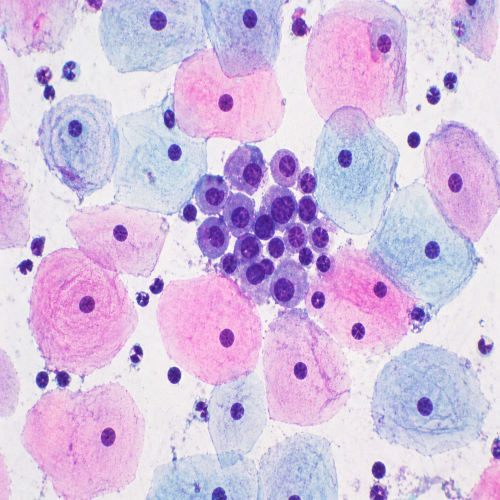

Grayscale


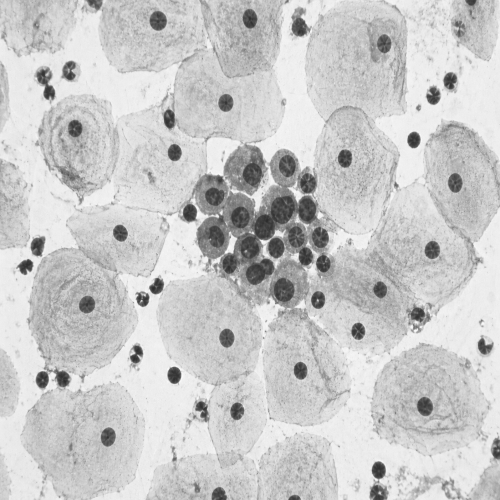

Adaptive Threshold


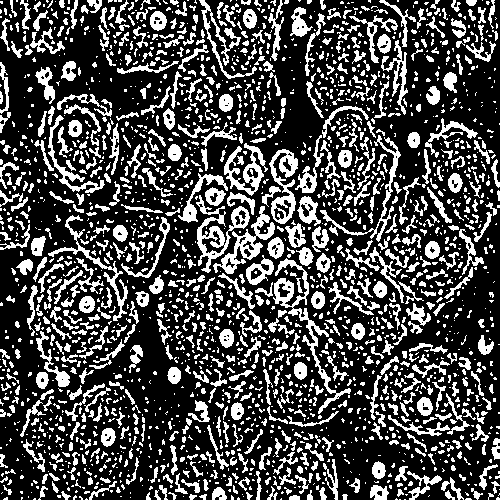

Opening


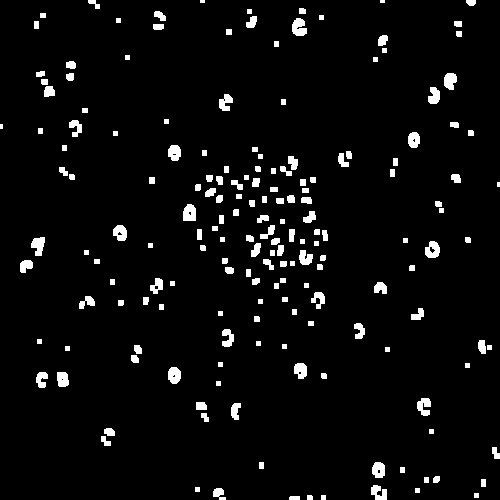

Foreground


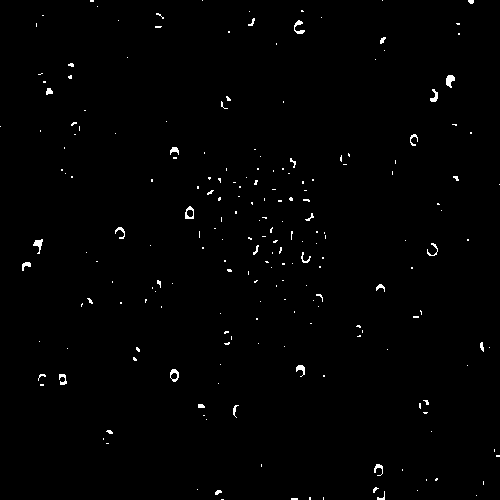

Hasil Segmentasi Watershed


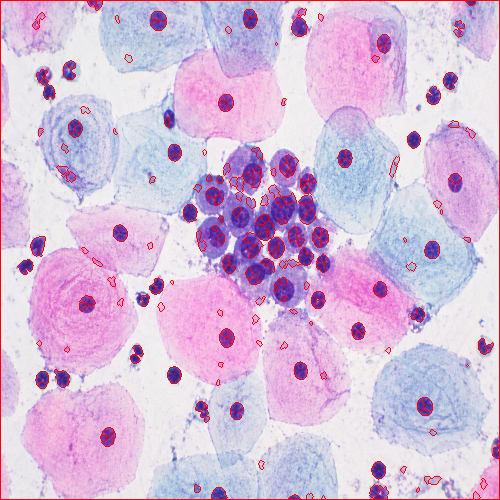

Proses segmentasi selesai


In [5]:
# ==========================================
# Segmentasi Pap Smear
# Adaptive Threshold + Watershed
# ==========================================

import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# ==========================================
# Upload gambar
# ==========================================

uploaded = files.upload()

# Ambil nama file
image_path = next(iter(uploaded))

# ==========================================
# Baca gambar
# ==========================================

img = cv2.imread(image_path)

# Resize gambar
img = cv2.resize(img, (500, 500))

print("Gambar Asli")
cv2_imshow(img)

# ==========================================
# Grayscale
# ==========================================

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Grayscale")
cv2_imshow(gray)

# ==========================================
# Blur
# ==========================================

blur = cv2.GaussianBlur(gray, (5,5), 0)

# ==========================================
# Adaptive Threshold
# ==========================================

thresh = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11,
    2
)

print("Adaptive Threshold")
cv2_imshow(thresh)

# ==========================================
# Morphology Opening
# ==========================================

kernel = np.ones((3,3), np.uint8)

opening = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

print("Opening")
cv2_imshow(opening)

# ==========================================
# Background
# ==========================================

sure_bg = cv2.dilate(opening, kernel, iterations=3)

# ==========================================
# Distance Transform
# ==========================================

dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

# ==========================================
# Foreground
# ==========================================

ret, sure_fg = cv2.threshold(
    dist_transform,
    0.4 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

print("Foreground")
cv2_imshow(sure_fg)

# ==========================================
# Unknown Area
# ==========================================

unknown = cv2.subtract(sure_bg, sure_fg)

# ==========================================
# Marker
# ==========================================

ret, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

# ==========================================
# Watershed
# ==========================================

markers = cv2.watershed(img, markers)

# Garis watershed warna merah
img[markers == -1] = [0, 0, 255]

print("Hasil Segmentasi Watershed")
cv2_imshow(img)

# ==========================================
# Simpan hasil
# ==========================================

cv2.imwrite("hasil_watershed.png", img)

print("Proses segmentasi selesai")